# All-model training / validation loss (EMA-smoothed)

Overlays every model's EMA-smoothed loss curves in one figure (Fig. `fig:loss`).
Loads `loss_history.csv` from each run under `plot_data/loss/<model>/`.

- **Dotted** — training loss   **Solid** — validation loss
- Rainbow colours + $M_1$–$M_6$ legend (worst → best CV accuracy).

Writes `plot_data/plots/figD1_loss.{pdf,png}`.


In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

LOSS_DIR = Path("/home/gate/rgc/plot_data/loss")
PLOTS_DIR = Path("/home/gate/rgc/plot_data/plots")
OUT_PDF = PLOTS_DIR / "figD1_loss.pdf"
OUT_PNG = PLOTS_DIR / "figD1_loss.png"

EMA_HALFLIFE = 250       # global_step units (~5 epochs)
LS_TRAIN, LS_VAL = ":", "-"

plt.rcParams.update({
    "font.size": 20, "axes.labelsize": 20,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
})

# folder name -> display name
DISPLAY = {
    "convnext_base": "ConvNeXT",
    "byol_downstream_no_mask_byol+mask_data": "BYOL-E2CNN",
    "byol_dsteerable_downstream": "BYOL-E2CNN",
    "vgg16": "VGG-16", "swin_b": "Swin-B",
    "resnet50": "ResNet-50", "vit_b_16": "ViT-B/16",
}
# serial order M1..M6 (worst -> best CV accuracy) with rainbow colours
ORDER = ["ConvNeXT", "BYOL-E2CNN", "VGG-16", "Swin-B", "ResNet-50", "ViT-B/16"]
COLOUR = {
    "ConvNeXT": "#bf5af2", "BYOL-E2CNN": "#0a84ff", "VGG-16": "#34c759",
    "Swin-B": "#ffcc00", "ResNet-50": "#ff9500", "ViT-B/16": "#ff3b30",
}

In [2]:
def ema(times, values, halflife):
    """Time-weighted EMA; halflife in the same units as *times*."""
    if len(values) <= 1:
        return list(values)
    out = [float(values[0])]
    ln2 = math.log(2)
    for i in range(1, len(values)):
        dt = max(float(times[i]) - float(times[i - 1]), 1e-9)
        a = 1.0 - math.exp(-ln2 * dt / halflife)
        out.append(a * float(values[i]) + (1.0 - a) * out[-1])
    return out


def series(df, col):
    """(epoch, ema-smoothed value) for one loss column."""
    sub = df[df[col].notna()]
    t = sub["global_step"] if "global_step" in sub.columns else sub["epoch"]
    return sub["epoch"].to_numpy(), ema(t.to_numpy(), sub[col].to_numpy(), EMA_HALFLIFE)


# discover runs and map to display names
runs = {DISPLAY.get(d.name, d.name): d / "loss_history.csv"
        for d in sorted(LOSS_DIR.iterdir())
        if (d / "loss_history.csv").is_file()}
print("runs:", {n: p.parent.name for n, p in runs.items()})

runs: {'BYOL-E2CNN': 'byol_downstream_no_mask_byol+mask_data', 'ConvNeXT': 'convnext_base', 'ResNet-50': 'resnet50', 'Swin-B': 'swin_b', 'VGG-16': 'vgg16', 'ViT-B/16': 'vit_b_16'}


wrote /home/gate/rgc/plot_data/plots/figD1_loss.pdf


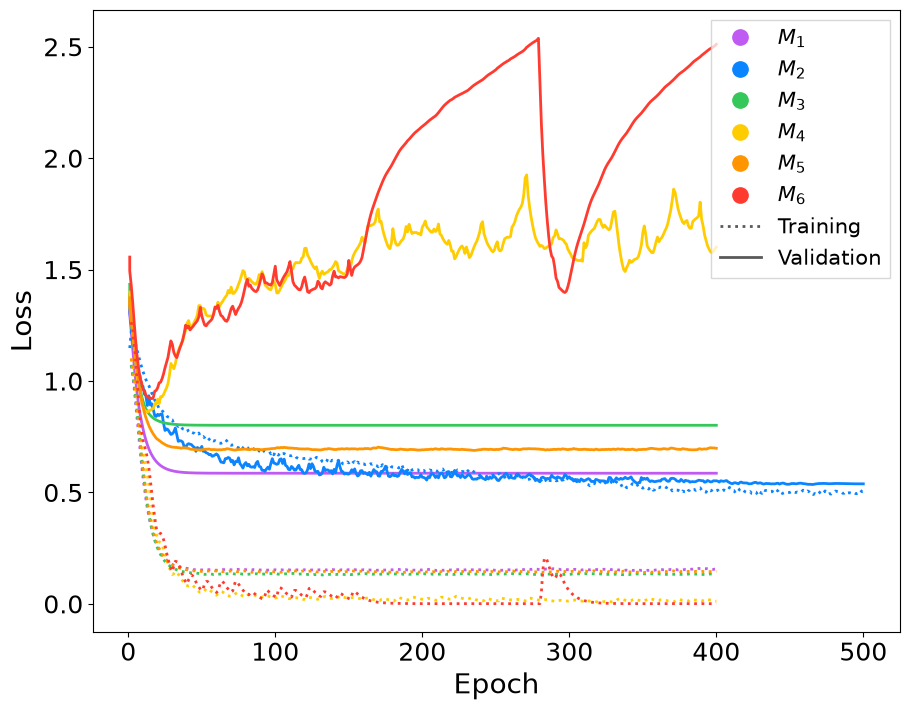

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 7.5))

for name in ORDER:
    csv = runs.get(name)
    if csv is None:
        continue
    df = pd.read_csv(csv)
    color = COLOUR[name]
    for col, ls in (("train_loss", LS_TRAIN), ("val_loss", LS_VAL)):
        ep, val = series(df, col)
        if len(val):
            ax.plot(ep, val, ls=ls, lw=2.0, color=color)

# Legend: coloured M1..M6 dots + train/val line styles
handles = [Line2D([], [], marker="o", ls="none", color=COLOUR[n], markersize=11,
                  label=fr"$M_{i}$")
           for i, n in enumerate(ORDER, start=1) if n in runs]
handles += [Line2D([], [], ls=LS_TRAIN, color="0.35", lw=2.0, label="Training"),
            Line2D([], [], ls=LS_VAL, color="0.35", lw=2.0, label="Validation")]

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(handles=handles, loc="upper right", fontsize=15,
          framealpha=0.75, fancybox=False)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
fig.tight_layout()
fig.savefig(OUT_PDF)
fig.savefig(OUT_PNG, dpi=200)
print("wrote", OUT_PDF)
plt.show()